In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# A notebook to analyze backtesting results

This simple notebook is to be used to 
- visualize the spread between the theoretical price of an option and the price of the corresponding hedging portfolio,
- compute the tracking error for the hedging portfolio.
It takes as an input the json file containing the output data produced by the hedger.

## Set the path to the file to investigate

In [15]:
FILE = 'TestOutputs/Test_5_3_Spot.json' #enter correct path here

In [16]:
df = pd.read_json(FILE, convert_dates=['date'])
df.sort_values(by='date', inplace=True)
df.set_index('date', inplace=True)

## Plot the portfolio value against the theoretical price

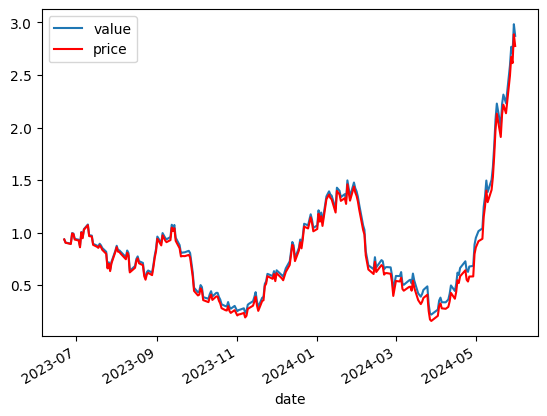

In [17]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
plt.show()

## Compute the PnL and tracking error

In [18]:
pnl = df['value'].iloc[-1] - df['price'].iloc[-1]
print(f'PnL: {pnl:.2f}')
tracking_error = (df['value'].iloc[-1] - df.price.iloc[-1])/df.price.iloc[0]
print(f'Tracking error: {tracking_error:.2%}')

PnL: 0.10
Tracking error: 10.26%


### Compute the cumulated transaction costs

In [14]:
df.head()

,value,deltas,deltasStdDev,price,priceStdDev,transactionCosts
date,,,,,,
2023-06-22,0.936157,"[0.035660855801536, 0.08383466676772601, 0.110...","[0, 0, 0, 0, 0]",0.936157,0,0
2023-06-23,0.905945,"[0.034859577922078, 0.082663420760148, 0.10810...","[0, 0, 0, 0, 0]",0.904678,0,0
2023-06-26,0.917400,"[0.035049806349524, 0.08311646321558801, 0.108...","[0, 0, 0, 0, 0]",0.914448,0,0
2023-06-27,0.897064,"[0.034761182948078, 0.08247336519633701, 0.107...","[0, 0, 0, 0, 0]",0.892523,0,0
2023-06-28,0.996425,"[0.036744544060636, 0.08643683054561001, 0.113...","[0, 0, 0, 0, 0]",0.992618,0,0


In [13]:
df['total_tc'] = df.transactionCosts.cumsum()

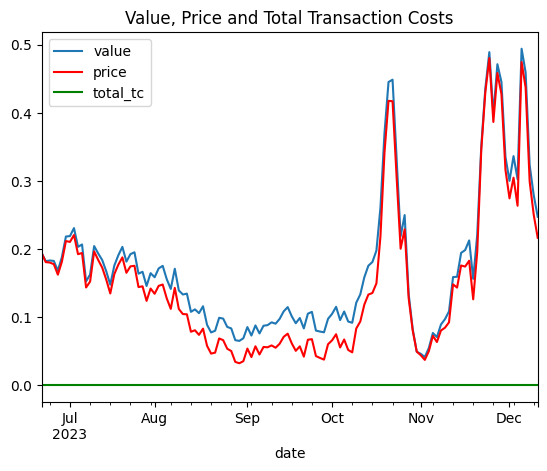

In [14]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
df.plot(y = 'total_tc', color = 'green', ax = ax)
plt.title('Value, Price and Total Transaction Costs')
plt.show()

In [15]:
total_pnl = df['value'].iloc[-1] - df['price'].iloc[-1] - df['total_tc'].iloc[-1]
print(f'Total PnL after transaction costs: {total_pnl:.2f}')

Total PnL after transaction costs: 0.03
